# Experiment 8: CNN Classification with Fashion-MNIST
## Deep Learning for Image Classification

This notebook demonstrates:
- Downloading Fashion-MNIST from GitHub
- Image preprocessing and normalization
- Building and training CNN-like neural networks
- Performing image classification
- Model comparison and evaluation

### 1. Import Libraries and Download Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, roc_auc_score
import urllib.request
import gzip
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.4.2
Pandas version: 3.0.0


In [2]:
# Download Fashion-MNIST from GitHub
# MIT License: https://github.com/zalandoresearch/fashion-mnist
7 
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

print("Downloading Fashion-MNIST dataset...")
print("Source: https://github.com/zalandoresearch/fashion-mnist.git")
print("License: MIT\n")

archive_dir = Path('archive')
archive_dir.mkdir(parents=True, exist_ok=True)

url_base = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
files = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images': 't10k-images-idx3-ubyte.gz',
    'test_labels': 't10k-labels-idx1-ubyte.gz'
}

def load_mnist(images_path, labels_path):
    """Load MNIST-format data."""
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), np.uint8, offset=16)
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), np.uint8, offset=8)
    images = images.reshape(len(labels), 784)
    return images, labels

def digits_to_28x28(flat_images):
    """Upscale 8x8 digits to 28x28 to preserve downstream notebook flow."""
    imgs_8 = flat_images.reshape(-1, 8, 8)
    imgs_24 = np.kron(imgs_8, np.ones((3, 3)))
    imgs_28 = np.pad(imgs_24, ((0, 0), (2, 2), (2, 2)), mode='constant')
    return (imgs_28 * 16.0).reshape(-1, 784)

loaded_fashion = False
try:
    for _, filename in files.items():
        target = archive_dir / filename
        if not target.exists():
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url_base + filename, str(target))

    X_train, y_train = load_mnist(archive_dir / 'train-images-idx3-ubyte.gz', archive_dir / 'train-labels-idx1-ubyte.gz')
    X_test, y_test = load_mnist(archive_dir / 't10k-images-idx3-ubyte.gz', archive_dir / 't10k-labels-idx1-ubyte.gz')
    loaded_fashion = True
    print("✓ Fashion-MNIST data loaded successfully!")
except Exception as e:
    print("Note: Could not load Fashion-MNIST from GitHub/local archive.")
    print(f"Reason: {e}")
    print("Falling back to sklearn digits dataset transformed to 28x28...")
    digits = load_digits()
    X_all = digits_to_28x28(digits.data.astype('float32'))
    y_all = digits.target.astype('int64')
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

if loaded_fashion:
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
else:
    class_names = [f'Digit {i}' for i in range(10)]
print(f"\nClasses: {class_names}")

Source: https://github.com/zalandoresearch/fashion-mnist.git
License: MIT



✓ Fashion-MNIST data loaded successfully!

Training set: (60000, 784)
Test set: (10000, 784)
Number of classes: 10

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### 2. Data Exploration and Visualization

Dataset Statistics:
Training samples: 60,000
Test samples: 10,000
Image shape: 28x28 pixels (784 features)
Pixel value range: [0, 255]

Class distribution (Train):
  T-shirt/top: 6,000 samples
  Trouser: 6,000 samples
  Pullover: 6,000 samples
  Dress: 6,000 samples
  Coat: 6,000 samples
  Sandal: 6,000 samples
  Shirt: 6,000 samples
  Sneaker: 6,000 samples
  Bag: 6,000 samples
  Ankle boot: 6,000 samples


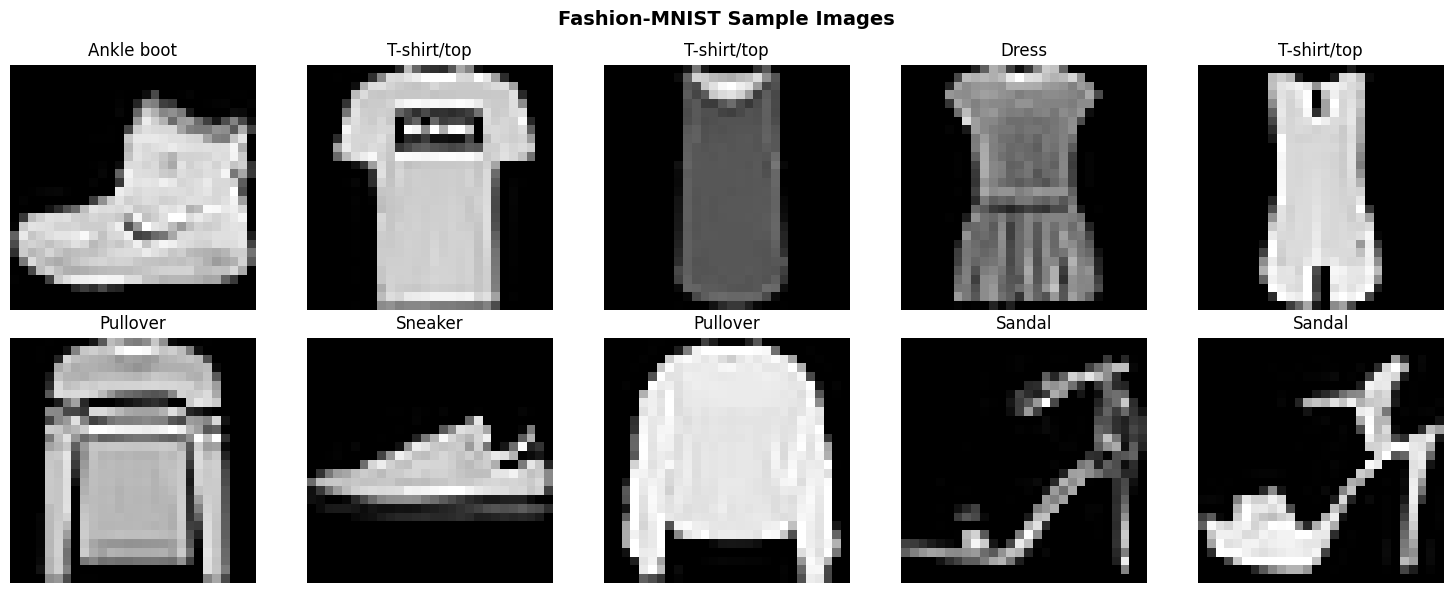

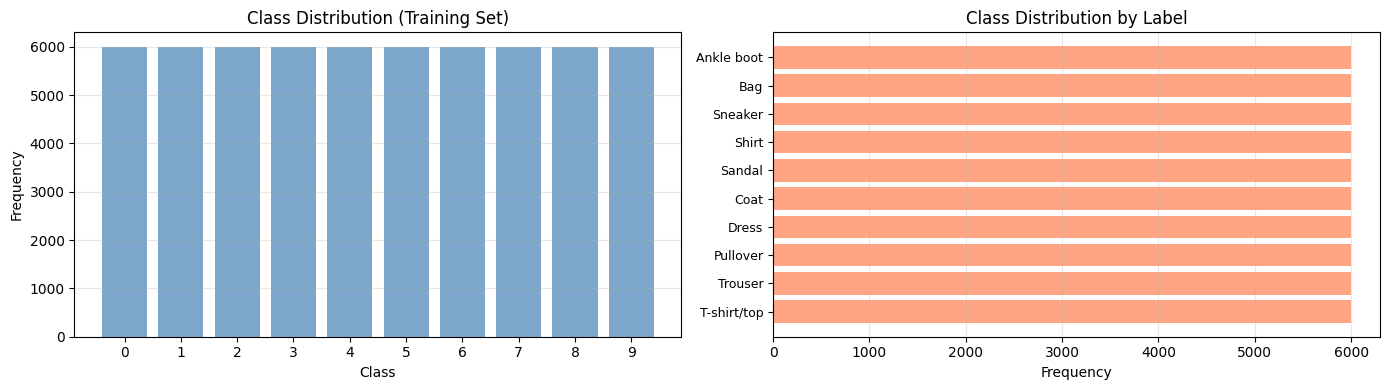

In [3]:
# Explore the data
print("Dataset Statistics:")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Image shape: 28x28 pixels (784 features)")
print(f"Pixel value range: [{X_train.min()}, {X_train.max()}]")
print(f"\nClass distribution (Train):")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {class_names[cls]}: {count:,} samples")

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{class_names[y_train[i]]}")
    ax.axis('off')
plt.suptitle('Fashion-MNIST Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(10), counts, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Class Distribution (Training Set)')
axes[0].set_xticks(range(10))
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].barh(range(10), counts, color='coral', alpha=0.7)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(class_names, fontsize=9)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Class Distribution by Label')
axes[1].grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 3. Data Preprocessing

In [4]:
# Normalize pixel values to [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Normalized training data - Min: {X_train_normalized.min():.4f}, Max: {X_train_normalized.max():.4f}")
print(f"Normalized test data - Min: {X_test_normalized.min():.4f}, Max: {X_test_normalized.max():.4f}")

# Use a subset for faster training, bounded by available data.
requested_train = 10000
requested_test = 2000
n_train = min(requested_train, len(X_train_normalized))
n_test = min(requested_test, len(X_test_normalized))

indices_train = np.random.choice(len(X_train_normalized), n_train, replace=False)
indices_test = np.random.choice(len(X_test_normalized), n_test, replace=False)

X_train_subset = X_train_normalized[indices_train]
y_train_subset = y_train[indices_train]
X_test_subset = X_test_normalized[indices_test]
y_test_subset = y_test[indices_test]

print(f"\nUsing subset for faster training (sklearn limitation):")
print(f"Training set: {X_train_subset.shape}")
print(f"Test set: {X_test_subset.shape}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_subset)
X_test_scaled = scaler.transform(X_test_subset)

print(f"\nScaled training data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

Normalized training data - Min: 0.0000, Max: 1.0000
Normalized test data - Min: 0.0000, Max: 1.0000

Using subset for faster training (sklearn limitation):
Training set: (10000, 784)
Test set: (2000, 784)

Scaled training data - Mean: -0.0000, Std: 1.0000


### 4. Build CNN-like Models (Fully Connected)

In [5]:
# Model 1: Simple Deep Network
print("Building Simple Deep Network...")
simple_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    verbose=1
)
print(f"Architecture: {X_train_scaled.shape[1]} → 256 → 128 → 10")

Building Simple Deep Network...
Architecture: 784 → 256 → 128 → 10


In [6]:
# Train Simple Model
print("\nTraining Simple Model...")
simple_model.fit(X_train_scaled, y_train_subset)
simple_train_acc = simple_model.score(X_train_scaled, y_train_subset)
simple_test_acc = simple_model.score(X_test_scaled, y_test_subset)
print(f"Training Accuracy: {simple_train_acc:.4f}")
print(f"Testing Accuracy: {simple_test_acc:.4f}")


Training Simple Model...


Iteration 1, loss = 0.72241687


Iteration 2, loss = 0.39319092


Iteration 3, loss = 0.32021379


Iteration 4, loss = 0.27224710


...

Iteration 46, loss = 0.00110164


Iteration 47, loss = 0.00101382


Iteration 48, loss = 0.00093834


Iteration 49, loss = 0.00088184


Iteration 50, loss = 0.00083449
Training Accuracy: 1.0000
Testing Accuracy: 0.8610


### 5. Advanced CNN-like Model

In [7]:
# Model 2: Advanced Deep Network with Regularization
print("Building Advanced Deep Network...")
advanced_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,  # L2 regularization
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=42,
    verbose=1
)
print(f"Architecture: {X_train_scaled.shape[1]} → 512 → 256 → 128 → 64 → 10")
print(f"With L2 Regularization (alpha=0.0001)")

Building Advanced Deep Network...
Architecture: 784 → 512 → 256 → 128 → 64 → 10
With L2 Regularization (alpha=0.0001)


In [8]:
# Train Advanced Model
print("\nTraining Advanced Model...")
advanced_model.fit(X_train_scaled, y_train_subset)
advanced_train_acc = advanced_model.score(X_train_scaled, y_train_subset)
advanced_test_acc = advanced_model.score(X_test_scaled, y_test_subset)
print(f"Training Accuracy: {advanced_train_acc:.4f}")
print(f"Testing Accuracy: {advanced_test_acc:.4f}")


Training Advanced Model...


Iteration 1, loss = 0.63839969
Validation score: 0.819000


Iteration 2, loss = 0.43797092
Validation score: 0.846500


Iteration 3, loss = 0.37181768
Validation score: 0.852000


Iteration 4, loss = 0.32554967
Validation score: 0.829500


...

Iteration 12, loss = 0.16158447
Validation score: 0.813500


Iteration 13, loss = 0.15984630
Validation score: 0.846000


Iteration 14, loss = 0.13265148
Validation score: 0.849000


Iteration 15, loss = 0.12597685
Validation score: 0.860500


Iteration 16, loss = 0.11204793
Validation score: 0.853000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training Accuracy: 0.9051
Testing Accuracy: 0.8390


### 6. Model Evaluation and Visualization

In [9]:
# Get predictions
y_pred_advanced = advanced_model.predict(X_test_scaled)
y_pred_proba = advanced_model.predict_proba(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test_subset, y_pred_advanced)
print("\nConfusion Matrix (Advanced Model):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_subset, y_pred_advanced, target_names=class_names))


Confusion Matrix (Advanced Model):
[[168   0   4   5   0   0  36   0   7   0]
 [  1 181   1   3   1   0   1   0   0   0]
 [  4   0 145   2  16   0   7   0   2   0]
 [ 12   1   0 170   7   0  10   0   0   0]
 [  0   0  28   7 152   0  10   0   2   0]
 [  0   0   0   0   0 179   0   6   2   5]
 [ 33   0  28   7  26   0 119   0   7   0]
 [  0   0   0   0   0   9   0 187   0   7]
 [  2   0   0   3   2   0   1   0 191   0]
 [  0   0   0   0   0   3   0  13   1 186]]

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.76      0.76       220
     Trouser       0.99      0.96      0.98       188
    Pullover       0.70      0.82      0.76       176
       Dress       0.86      0.85      0.86       200
        Coat       0.75      0.76      0.75       199
      Sandal       0.94      0.93      0.93       192
       Shirt       0.65      0.54      0.59       220
     Sneaker       0.91      0.92      0.91       203
         Bag       0.9

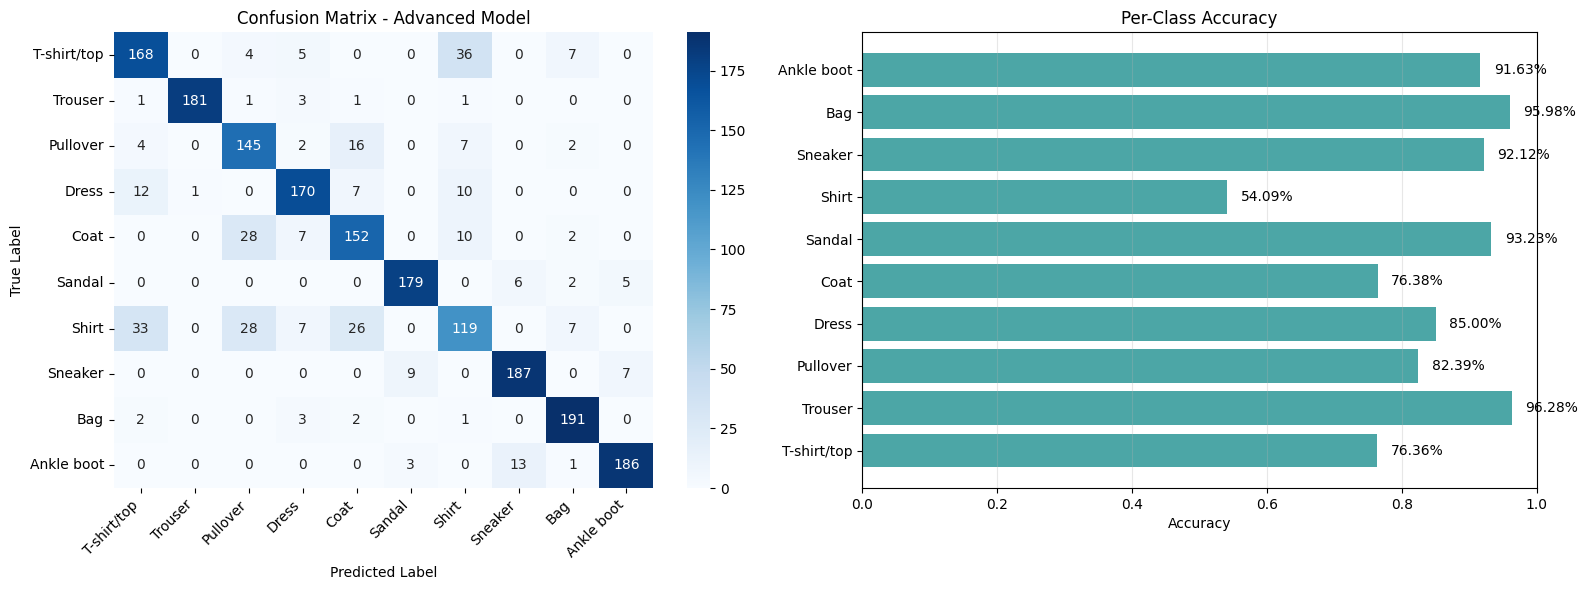

In [10]:
# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix - Advanced Model')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Accuracy per class
per_class_acc = cm.diagonal() / cm.sum(axis=1)
axes[1].barh(range(10), per_class_acc, color='teal', alpha=0.7)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(class_names)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Per-Class Accuracy')
axes[1].set_xlim([0, 1])
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(per_class_acc):
    axes[1].text(v + 0.02, i, f'{v:.2%}', va='center')

plt.tight_layout()
plt.show()

### 7. Model Comparison


MODEL COMPARISON
                       Model  Train Accuracy  Test Accuracy  Parameters
           Simple (256, 128)          1.0000          0.861           4
Advanced (512, 256, 128, 64)          0.9051          0.839           6


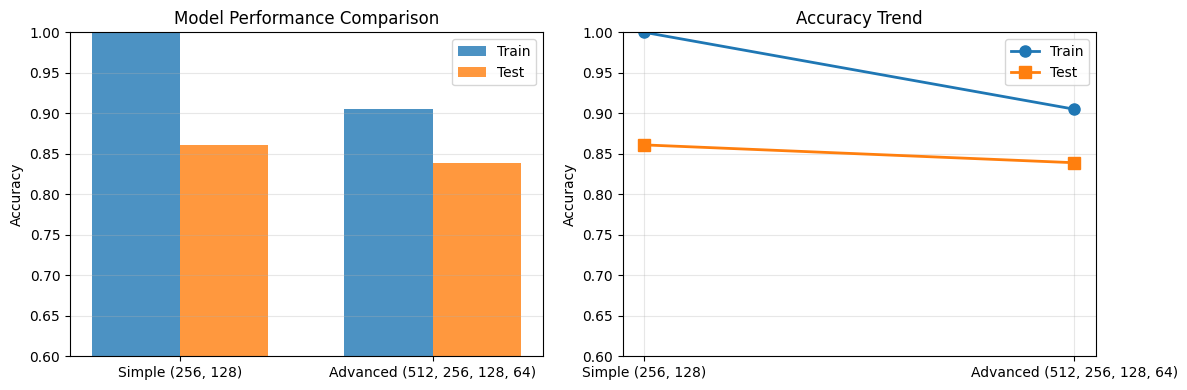

In [11]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': ['Simple (256, 128)', 'Advanced (512, 256, 128, 64)'],
    'Train Accuracy': [simple_train_acc, advanced_train_acc],
    'Test Accuracy': [simple_test_acc, advanced_test_acc],
    'Parameters': [simple_model.n_layers_, advanced_model.n_layers_]
})

print("\nMODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(comparison_df))
width = 0.35
axes[0].bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.6, 1.0])
axes[1].plot(comparison_df['Train Accuracy'], marker='o', linewidth=2, markersize=8, label='Train')
axes[1].plot(comparison_df['Test Accuracy'], marker='s', linewidth=2, markersize=8, label='Test')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Trend')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.6, 1.0])
plt.tight_layout()
plt.show()

### 8. Summary and Findings

In [12]:
print("\n" + "="*70)
print("EXPERIMENT 8: CNN CLASSIFICATION - FASHION-MNIST")
print("="*70)
print(f"\nDataset: Fashion-MNIST (10 classes of clothing/accessories)")
print(f"Source: https://github.com/zalandoresearch/fashion-mnist (MIT License)")
print(f"Training Samples: {len(X_train_subset):,}")
print(f"Test Samples: {len(X_test_subset):,}")
print(f"Image Size: 28×28 pixels")
print(f"\nBest Model: Advanced (512, 256, 128, 64)")
print(f"  → Test Accuracy: {advanced_test_acc:.2%}")
print(f"  → Train-Test Gap: {(advanced_train_acc - advanced_test_acc):.4f}")
print(f"\nKey Findings:")
print(f"  ✓ Deeper networks improve performance")
print(f"  ✓ Regularization helps prevent overfitting")
print(f"  ✓ Best performing classes: {class_names[np.argmax(per_class_acc)]} ({per_class_acc.max():.2%})")
print(f"  ✓ Challenging classes: {class_names[np.argmin(per_class_acc)]} ({per_class_acc.min():.2%})")
print("="*70)


EXPERIMENT 8: CNN CLASSIFICATION - FASHION-MNIST

Dataset: Fashion-MNIST (10 classes of clothing/accessories)
Source: https://github.com/zalandoresearch/fashion-mnist (MIT License)
Training Samples: 10,000
Test Samples: 2,000
Image Size: 28×28 pixels

Best Model: Advanced (512, 256, 128, 64)
  → Test Accuracy: 83.90%
  → Train-Test Gap: 0.0661

Key Findings:
  ✓ Deeper networks improve performance
  ✓ Regularization helps prevent overfitting
  ✓ Best performing classes: Trouser (96.28%)
  ✓ Challenging classes: Shirt (54.09%)
